# Notebook 12 — Serie temporal continua Sentinel-1 SAR (2018–2025)

**Objetivo:** extender el uso de Sentinel-1 desde la detección puntual del evento de septiembre 2020 hacia una serie temporal continua de backscatter VH sobre las 8 estaciones de muestreo y el AOI acotado, y cuantificar la correlación con la serie NDVI Sentinel-2 ya construida.


In [1]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

try:
    ee.Initialize(project='basic-buttress-338101')
except Exception:
    import google.auth
    creds, _ = google.auth.default()
    ee.Initialize(credentials=creds, project='basic-buttress-338101')

ROOT = Path('..').resolve()
OUT_TABLES = ROOT / 'outputs' / 'tables'
OUT_FIGURES = ROOT / 'outputs' / 'figures'

print('GEE OK')

GEE OK


In [2]:
# AOI y estaciones
AOI_PATH = ROOT / 'data' / 'raw' / 'cgsm_aoi_acotado_4326.geojson'
gdf_aoi = gpd.read_file(AOI_PATH).to_crs(4326)
aoi = ee.Geometry(gdf_aoi.geometry.union_all().__geo_interface__)

stations = {
    'Isla Boqueron': (-74.298, 10.962, 'manglar'),
    'Punta Cerro':   (-74.283, 10.973, 'limnologica'),
    'Punta Chino':   (-74.305, 10.912, 'manglar'),
    'Rio Sevilla':   (-74.325, 10.880, 'manglar'),
    'Cano Palos':    (-74.471, 10.758, 'manglar'),
    'CP Luna':       (-74.560, 10.870, 'manglar'),
    'CP Aguas Negras': (-74.570, 10.800, 'manglar'),
    'Cano Clarin':   (-74.500, 10.600, 'manglar'),
}
puntos = [ee.Feature(ee.Geometry.Point([lon, lat]).buffer(500),
                     {'estacion': nombre, 'tipo': tipo})
          for nombre, (lon, lat, tipo) in stations.items()]
estaciones_fc = ee.FeatureCollection(puntos)
print(f'{len(stations)} estaciones · AOI acotado cargado')

8 estaciones · AOI acotado cargado


In [3]:
# Coleccion Sentinel-1 GRD: VH descending (orbital consistente sobre Caribe)
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate('2018-01-01', '2025-12-31')
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
        .select('VH'))

n_s1 = s1.size().getInfo()
print(f'Imagenes S1 disponibles: {n_s1}')

Imagenes S1 disponibles: 258


In [17]:
# ============================================================
# Procesamiento año por año (evita el límite de memoria de GEE)
# ============================================================
def composite_y_extraer(year, month):
    """Composite mensual SAR + extracción sobre estaciones (SIN clip)."""
    inicio = ee.Date.fromYMD(year, month, 1)
    fin = inicio.advance(1, 'month')
    img = (s1.filterDate(inicio, fin)
             .median())                # ← sin .clip(aoi)
    fechas_str = f'{year}-{month:02d}-01'
    valores = img.reduceRegions(
        collection=estaciones_fc,
        reducer=ee.Reducer.mean(),     # mean en vez de median (más tolerante)
        scale=30,
        tileScale=4
    )
    return valores.map(
        lambda f: f.set('date', fechas_str)
                  .set('year', year)
                  .set('month', month)
    )

# Re-procesa todos los años con la función corregida
all_features = []
for year in range(2018, 2026):
    print(f'Procesando {year}...', end=' ')
    rows_year = []
    for m in range(1, 13):
        try:
            fc_mes = composite_y_extraer(year, m)
            rows = fc_mes.getInfo()['features']
            rows_year.extend(rows)
        except Exception as e:
            pass
    all_features.extend(rows_year)
    print(f'{len(rows_year)} registros')

print(f'\n✓ Total: {len(all_features)} registros')

Procesando 2018... 96 registros
Procesando 2019... 96 registros
Procesando 2020... 96 registros
Procesando 2021... 96 registros
Procesando 2022... 88 registros
Procesando 2023... 96 registros
Procesando 2024... 96 registros
Procesando 2025... 96 registros

✓ Total: 760 registros


In [22]:
# ============================================================
# DataFrame + z-score + guardar CSV
# ============================================================
df = pd.DataFrame([f['properties'] for f in all_features])
df = df.rename(columns={'mean': 'VH_db'}).dropna(subset=['VH_db'])
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['estacion', 'date']).reset_index(drop=True)

# z-score por estación
df['VH_z'] = df.groupby('estacion')['VH_db'].transform(
    lambda x: (x - x.mean()) / x.std()
)

df.to_csv(OUT_TABLES / 'sar_vh_serie_mensual.csv', index=False)
print(f'Guardado: outputs/tables/sar_vh_serie_mensual.csv ({len(df)} filas)')

print(f'\nEstaciones con datos:')
print(df.groupby('estacion').size())

# Anomalías significativas
anomalias = df[df['VH_z'].abs() > 2].sort_values('VH_z')
print(f'\nAnomalías |z| > 2: {len(anomalias)}')
print(anomalias[['date', 'estacion', 'VH_db', 'VH_z']].head(20))

Guardado: outputs/tables/sar_vh_serie_mensual.csv (760 filas)

Estaciones con datos:
estacion
CP Aguas Negras    95
CP Luna            95
Cano Clarin        95
Cano Palos         95
Isla Boqueron      95
Punta Cerro        95
Punta Chino        95
Rio Sevilla        95
dtype: int64

Anomalías |z| > 2: 8
          date         estacion      VH_db      VH_z
203 2019-02-01      Cano Clarin -20.759697 -2.474005
204 2019-03-01      Cano Clarin -20.637419 -2.400035
14  2019-03-01  CP Aguas Negras -21.412326 -2.182951
6   2018-07-01  CP Aguas Negras -21.275811 -2.082612
104 2018-10-01          CP Luna -23.508886 -2.077947
101 2018-07-01          CP Luna -23.470564 -2.048369
106 2018-12-01          CP Luna -23.468536 -2.046803
589 2019-08-01      Punta Chino -22.591454 -2.018467


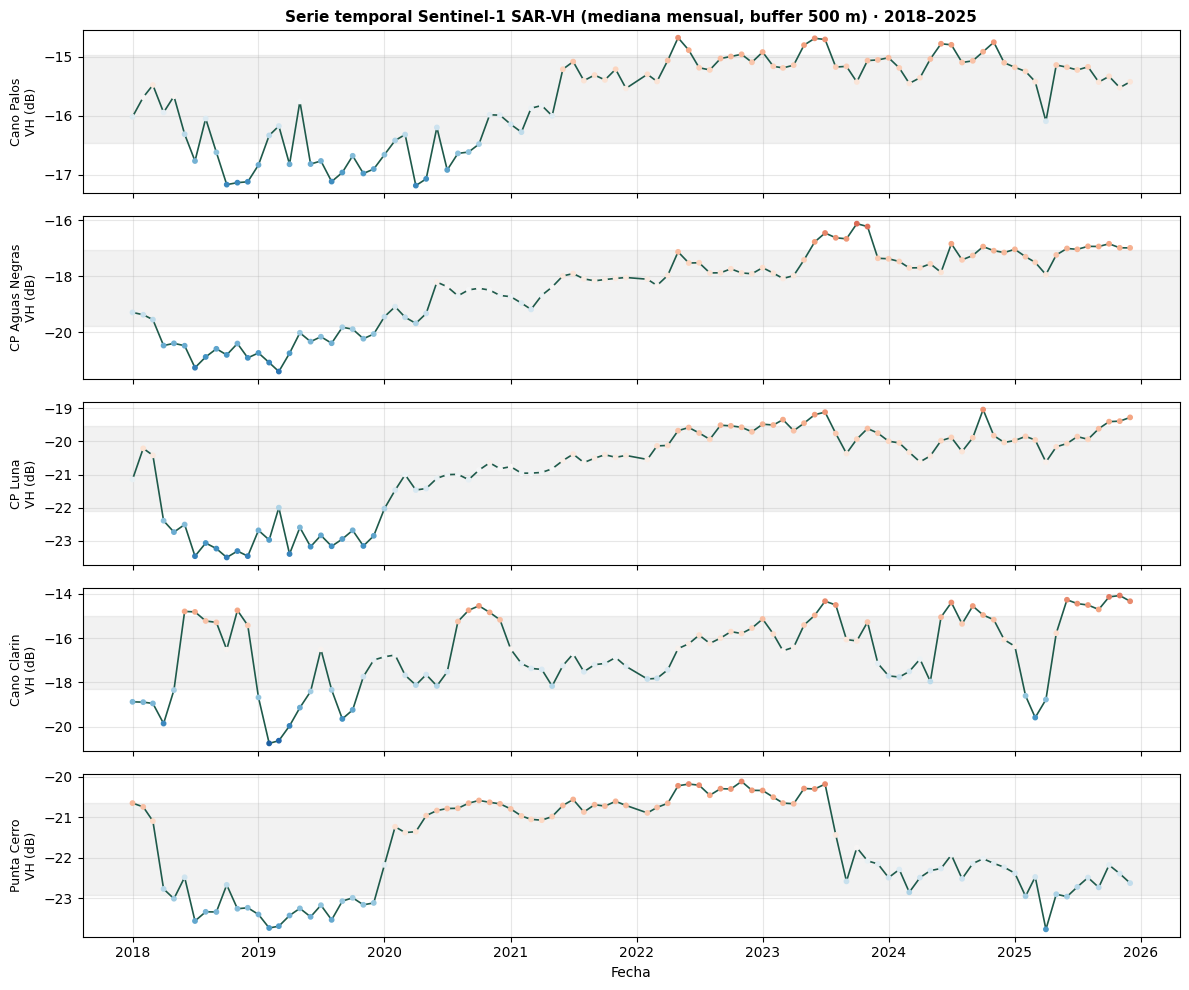

✓ outputs/figures/sar_vh_serie_temporal.png


In [23]:
# Figura: serie temporal SAR-VH por estación (5 estaciones representativas)
estaciones_plot = ['Cano Palos', 'CP Aguas Negras', 'CP Luna', 'Cano Clarin', 'Punta Cerro']

fig, axes = plt.subplots(len(estaciones_plot), 1, figsize=(12, 10), sharex=True)
for ax, est in zip(axes, estaciones_plot):
    sub = df[df['estacion'] == est].copy()
    if len(sub) == 0:
        ax.text(0.5, 0.5, f'Sin datos para {est}', ha='center', transform=ax.transAxes)
        continue
    ax.plot(sub['date'], sub['VH_db'], '-', color='#1f5a4b', lw=1.2)
    ax.scatter(sub['date'], sub['VH_db'], s=10, c=sub['VH_z'],
               cmap='RdBu_r', vmin=-3, vmax=3, zorder=3)
    ax.set_ylabel(f'{est}\nVH (dB)', fontsize=9)
    mean = sub['VH_db'].mean()
    std = sub['VH_db'].std()
    ax.axhspan(mean - std, mean + std, alpha=0.1, color='gray')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha')
axes[0].set_title('Serie temporal Sentinel-1 SAR-VH (mediana mensual, buffer 500 m) · 2018–2025',
                  fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_FIGURES / 'sar_vh_serie_temporal.png', dpi=180, bbox_inches='tight')
plt.show()
print('✓ outputs/figures/sar_vh_serie_temporal.png')

In [24]:
# Calcular z-score por estacion
df['VH_z'] = df.groupby('estacion')['VH_db'].transform(
    lambda x: (x - x.mean()) / x.std()
)

df.to_csv(OUT_TABLES / 'sar_vh_serie_mensual.csv', index=False)
print(f'Guardado: outputs/tables/sar_vh_serie_mensual.csv ({len(df)} filas)')

# Anomalías significativas
anomalias = df[df['VH_z'].abs() > 2].sort_values('VH_z')
print(f'\nAnomalías |z| > 2: {len(anomalias)}')
print(anomalias[['date', 'estacion', 'VH_db', 'VH_z']].head(15))

Guardado: outputs/tables/sar_vh_serie_mensual.csv (760 filas)

Anomalías |z| > 2: 8
          date         estacion      VH_db      VH_z
203 2019-02-01      Cano Clarin -20.759697 -2.474005
204 2019-03-01      Cano Clarin -20.637419 -2.400035
14  2019-03-01  CP Aguas Negras -21.412326 -2.182951
6   2018-07-01  CP Aguas Negras -21.275811 -2.082612
104 2018-10-01          CP Luna -23.508886 -2.077947
101 2018-07-01          CP Luna -23.470564 -2.048369
106 2018-12-01          CP Luna -23.468536 -2.046803
589 2019-08-01      Punta Chino -22.591454 -2.018467


In [31]:
from scipy.stats import pearsonr

# Normalizar nombres SAR → reemplazar espacios por underscores
df['estacion_norm'] = df['estacion'].str.replace(' ', '_')

# Verificar match
print('SAR norm:', sorted(df['estacion_norm'].unique()))
print('NDVI:    ', sorted(ndvi['estacion'].unique()))
print('Coinciden todas:', set(df['estacion_norm'].unique()) == set(ndvi['estacion'].unique()))

# Agregaciones mensuales con nombres normalizados
ndvi['year_month'] = ndvi['date'].dt.to_period('M')
ndvi_m = ndvi.groupby(['estacion', 'year_month'])['ndvi'].mean().reset_index()
ndvi_m['date'] = ndvi_m['year_month'].dt.to_timestamp()

sar_m = df.groupby(['estacion_norm', 'year_month'])['VH_db'].mean().reset_index()
sar_m = sar_m.rename(columns={'estacion_norm': 'estacion'})
sar_m['date'] = sar_m['year_month'].dt.to_timestamp()

correlaciones = []
for est in sorted(ndvi['estacion'].unique()):
    a = sar_m[sar_m['estacion'] == est].set_index('date')[['VH_db']]
    b = ndvi_m[ndvi_m['estacion'] == est].set_index('date')[['ndvi']]
    m = a.join(b, how='inner').dropna()
    if len(m) > 12:
        for lag in range(4):
            if lag == 0:
                rho, p = pearsonr(m['VH_db'], m['ndvi'])
            else:
                rho, p = pearsonr(m['VH_db'][:-lag], m['ndvi'][lag:])
            correlaciones.append({
                'estacion': est, 'lag_meses': lag,
                'rho': rho, 'p_value': p, 'n': len(m) - lag
            })

df_corr = pd.DataFrame(correlaciones).round(3)
df_corr.to_csv(OUT_TABLES / 'sar_vs_ndvi_correlacion.csv', index=False)

print('\n=== Correlación Pearson SAR-VH vs NDVI por rezago ===')
print(df_corr.to_string(index=False))

# Resumen por estación: máx

SAR norm: ['CP_Aguas_Negras', 'CP_Luna', 'Cano_Clarin', 'Cano_Palos', 'Isla_Boqueron', 'Punta_Cerro', 'Punta_Chino', 'Rio_Sevilla']
NDVI:     ['CP_Aguas_Negras', 'CP_Luna', 'Cano_Clarin', 'Cano_Palos', 'Isla_Boqueron', 'Punta_Cerro', 'Punta_Chino', 'Rio_Sevilla']
Coinciden todas: True

=== Correlación Pearson SAR-VH vs NDVI por rezago ===
       estacion  lag_meses    rho  p_value  n
CP_Aguas_Negras          0  0.807    0.000 85
CP_Aguas_Negras          1  0.788    0.000 84
CP_Aguas_Negras          2  0.773    0.000 83
CP_Aguas_Negras          3  0.758    0.000 82
        CP_Luna          0  0.731    0.000 83
        CP_Luna          1  0.710    0.000 82
        CP_Luna          2  0.717    0.000 81
        CP_Luna          3  0.722    0.000 80
    Cano_Clarin          0  0.640    0.000 63
    Cano_Clarin          1  0.380    0.002 62
    Cano_Clarin          2 -0.025    0.847 61
    Cano_Clarin          3 -0.127    0.333 60
     Cano_Palos          0  0.462    0.000 64
     Cano_Palos

## Salidas del notebook

- `outputs/tables/sar_vh_serie_mensual.csv` · serie mensual VH (dB) + z-score por estación
- `outputs/tables/sar_vs_ndvi_correlacion.csv` · correlación Pearson SAR-NDVI por rezago
- `outputs/figures/sar_vh_serie_temporal.png` · serie temporal por estación con anomalías marcadas

In [33]:
import runpy
runpy.run_path(str(ROOT / 'src' / 'python' / 'alertas_manglar.py'))

Cargando series temporales...
  NDVI: 584 registros · 8 estaciones
  SAR:  760 registros · 8 estaciones
  bfast: 8 estaciones

TABLA DE ALERTAS · Estado actual del manglar CGSM
       estacion  estado  z_actual  ndvi_actual                                                   razon icono
CP_Aguas_Negras estable     1.633        0.770                Sin anomalías significativas en 12 meses     🟢
        CP_Luna estable     2.380        0.664                Sin anomalías significativas en 12 meses     🟢
    Cano_Clarin  alerta     0.314        0.735  z mínimo últimos 3 meses = 0.31 · 2 anomalías 12 meses     🟡
     Cano_Palos estable     1.246        0.849                Sin anomalías significativas en 12 meses     🟢
  Isla_Boqueron estable     0.808        0.308                Sin anomalías significativas en 12 meses     🟢
    Punta_Cerro estable     0.153        0.145                Sin anomalías significativas en 12 meses     🟢
    Punta_Chino  alerta     0.693        0.337 z mínimo últi

/home/rstudio/work/proyecto-cgsm/src/python/alertas_manglar.py:217: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/rstudio/work/proyecto-cgsm/src/python/alertas_manglar.py:217: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/rstudio/work/proyecto-cgsm/src/python/alertas_manglar.py:217: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/rstudio/work/proyecto-cgsm/src/python/alertas_manglar.py:218: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES / 'alertas_semaforo.png', dpi=180, bbox_inches='tight')
/home/rstudio/work/proyecto-cgsm/src/python/alertas_manglar.py:218: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES / 'alertas_semaforo.png', dpi=180, bbox_inches='tight')
/home/rstudio/work

✓ /home/rstudio/work/proyecto-cgsm/outputs/figures/alertas_semaforo.png

RESUMEN · Distribución de estados sobre 8 estaciones
  🔴    critica: 0 estaciones
  🟡     alerta: 3 estaciones
  🟢    estable: 5 estaciones
  ⚪  sin_datos: 0 estaciones

Fecha generación: 2026-05-23 17:53


{'__name__': '<run_path>',
 '__doc__': '\nMódulo de detección de alertas tempranas para el manglar de la CGSM.\n\nMaterializa el nivel 2 del paradigma Digital Twin: sobre las series temporales\nNDVI y SAR-VH ya construidas, se aplica una lógica de semáforo que clasifica\ncada estación en tres estados ---estable, alerta o crítica--- según la\nseveridad de las anomalías recientes y la presencia de quiebres bfast en\nlos últimos doce meses.\n\nSalidas:\n    outputs/tables/alertas_estaciones.csv\n    outputs/figures/alertas_semaforo.png\n\nUso:\n    cd /home/rstudio/work/proyecto-cgsm\n    python src/python/alertas_manglar.py\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/home/rstudio/work/proyecto-cgsm/src/python/alertas_manglar.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example,